# FineWeb 2 Language Overview

This short notebook summarizes the language coverage of `fineweb2-language-distribution.csv`. I focus on
train/test rows (dropping subsets tagged as *_removed*) so we can understand usable data. The cells below
report the main counts plus a few quick charts.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

data_path = Path("fineweb2-language-distribution.csv")
raw_df = pd.read_csv(data_path)


def most_common(series: pd.Series):
    non_empty = series.dropna()
    if non_empty.empty:
        return None
    mode = non_empty.mode()
    return mode.iat[0] if not mode.empty else None


usable_df = raw_df[~raw_df["subset"].str.contains("removed", case=False, na=False)].copy()

numeric_cols = ["words", "documents", "utf8_bytes", "parquet_bytes"]
for col in numeric_cols:
    usable_df[col] = pd.to_numeric(usable_df[col], errors="coerce")

lang_summary = (
    usable_df.groupby("code").agg(
        name=("name", "first"),
        family=("family", most_common),
        script=("script", most_common),
        documents=("documents", "sum"),
        words=("words", "sum"),
    )
    .reset_index()
)

lang_summary["family"] = lang_summary["family"].fillna("Unknown")
lang_summary["script"] = lang_summary["script"].fillna("Unknown")
lang_summary["documents"] = lang_summary["documents"].fillna(0).astype(int)

family_counts = lang_summary.groupby("family")["code"].nunique().sort_values(ascending=False)
family_counts_df = family_counts.reset_index().rename(columns={"code": "language_count"})

script_counts = lang_summary.groupby("script")["code"].nunique().sort_values(ascending=False)
script_counts_df = script_counts.reset_index().rename(columns={"code": "language_count"})

langs_over_30k = lang_summary[lang_summary["documents"] > 30_000].sort_values("documents", ascending=False)
langs_over_10k = lang_summary[lang_summary["documents"] > 500].sort_values("documents", ascending=False)

metrics = pd.DataFrame(
    {
        "metric": [
            "Total languages",
            "Language families",
            "Scripts",
            "Languages with >30k documents",
            "Languages with >10k documents",
        ],
        "value": [
            lang_summary["code"].nunique(),
            lang_summary["family"].nunique(),
            lang_summary["script"].nunique(),
            len(langs_over_30k),
            len(langs_over_10k),
        ],
    }
)


## Coverage snapshot

In [14]:
display(metrics.set_index("metric"))

print("\nLanguages per family (sorted):")
display(family_counts_df)

print("\nLanguages per script (sorted):")
display(script_counts_df)

print(f"\nLanguages with >30k documents: showing top 20 of {len(langs_over_30k)}")
display(langs_over_30k[["code", "name", "family", "documents"]].head(20))

print(f"\nLanguages with >10k documents: showing top 20 of {len(langs_over_10k)}")
display(langs_over_10k[["code", "name", "family", "documents"]].head(20))

,value
metric,
Total languages,1812
Language families,103
Scripts,35
Languages with >30k documents,154
Languages with >10k documents,635



Languages per family (sorted):


,family,language_count
0,Niger-Congo,376
1,Austronesian,300
2,Indo-European,160
3,Trans-New Guinea,133
4,Sino-Tibetan,103
...,...,...
98,South-Central Papuan,1
99,Siouan-Catawban,1
100,Yaguan,1
101,Yuat,1



Languages per script (sorted):


,script,language_count
0,Latn,1609
1,Cyrl,65
2,Arab,32
3,Deva,28
4,Ethi,11
5,Thai,7
6,Cans,6
7,Mymr,5
8,Beng,5
9,Hebr,4



Languages with >30k documents: showing top 20 of 154


,code,name,family,documents
1390,rus,Russian,Indo-European,699118293
316,cmn,Mandarin Chinese,Sino-Tibetan,636092280
382,deu,German,Indo-European,496029661
1464,spa,Spanish,Indo-European,441328231
669,jpn,Japanese,Japonic,400164452
477,fra,French,Indo-European,360103218
650,ita,Italian,Indo-European,239025466
1303,por,Portuguese,Indo-European,199771825
1301,pol,Polish,Indo-European,152003298
1163,nld,Dutch,Indo-European,147334553



Languages with >10k documents: showing top 20 of 635


,code,name,family,documents
1390,rus,Russian,Indo-European,699118293
316,cmn,Mandarin Chinese,Sino-Tibetan,636092280
382,deu,German,Indo-European,496029661
1464,spa,Spanish,Indo-European,441328231
669,jpn,Japanese,Japonic,400164452
477,fra,French,Indo-European,360103218
650,ita,Italian,Indo-European,239025466
1303,por,Portuguese,Indo-European,199771825
1301,pol,Polish,Indo-European,152003298
1163,nld,Dutch,Indo-European,147334553


## Visual summaries

/tmp/ipykernel_1953879/2333326653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1953879/2333326653.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


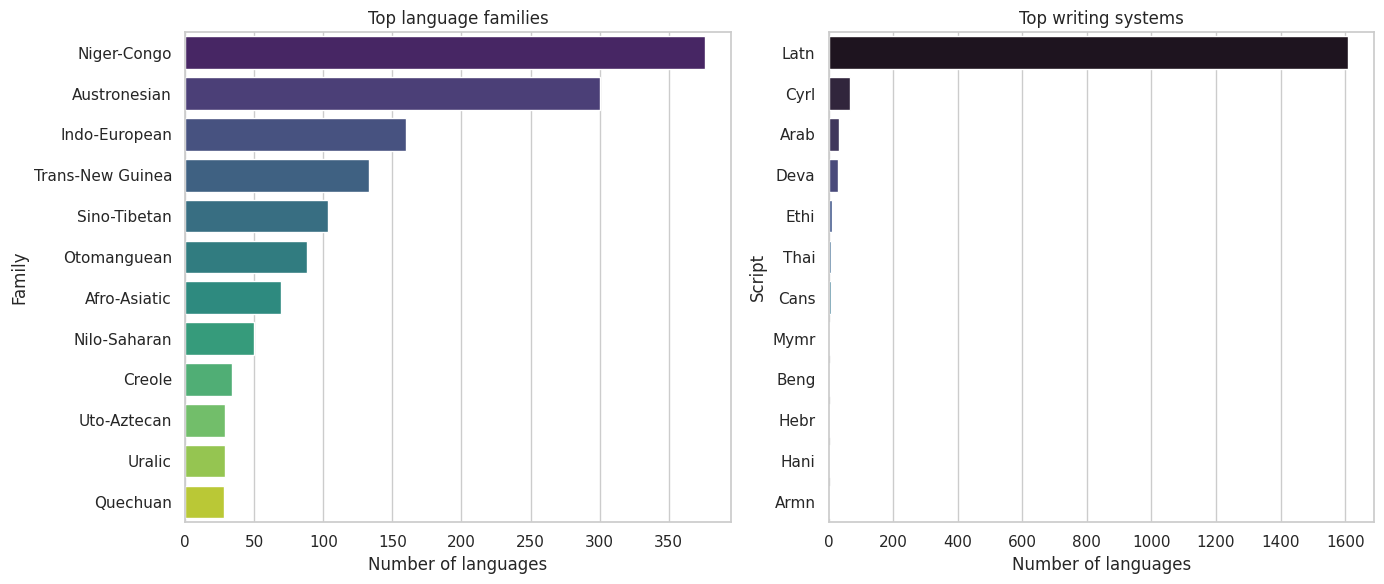

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

family_plot = family_counts_df.head(12)
sns.barplot(
    data=family_plot,
    x="language_count",
    y="family",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Top language families")
axes[0].set_xlabel("Number of languages")
axes[0].set_ylabel("Family")

script_plot = script_counts_df.head(12)
sns.barplot(
    data=script_plot,
    x="language_count",
    y="script",
    palette="mako",
    ax=axes[1],
)
axes[1].set_title("Top writing systems")
axes[1].set_xlabel("Number of languages")
axes[1].set_ylabel("Script")

plt.tight_layout()
plt.show()


/tmp/ipykernel_1953879/1606111587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


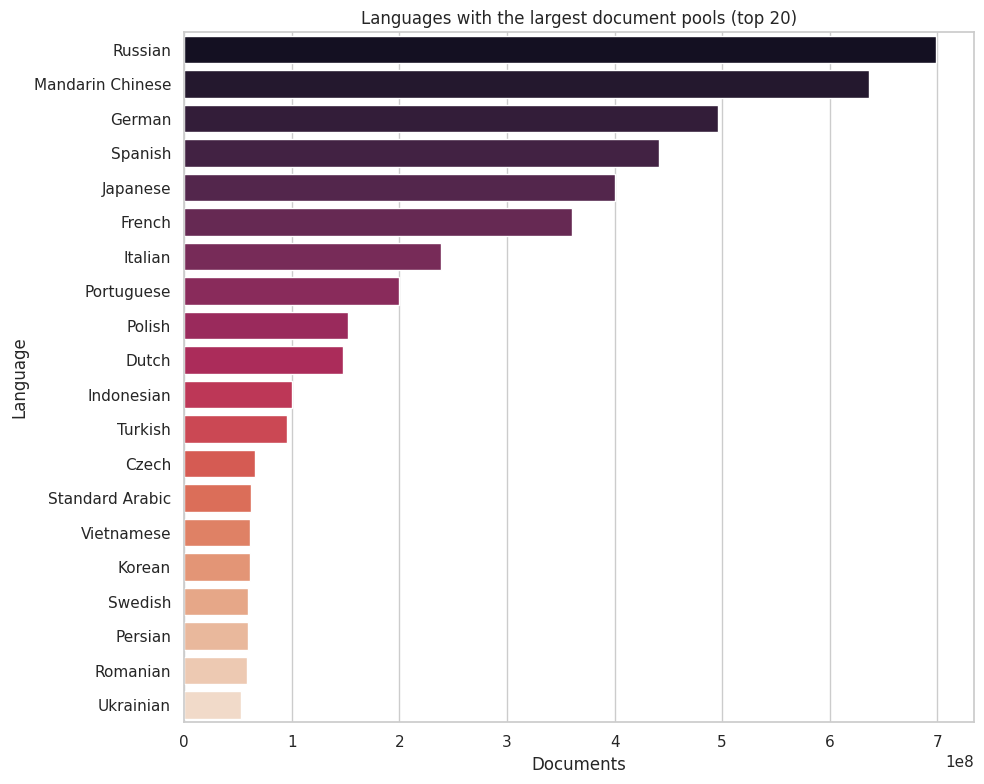

In [16]:
top_lang_docs = langs_over_30k.head(20)
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_lang_docs,
    x="documents",
    y="name",
    palette="rocket",
)
plt.title("Languages with the largest document pools (top 20)")
plt.xlabel("Documents")
plt.ylabel("Language")
plt.tight_layout()
plt.show()


### Takeaways

- FineWeb 2 covers a very wide set of languages (mostly Latin-script) spread across more than one hundred families.
- Only ~150 languages currently pass the 30k document threshold, skewed toward high-resource groups.
- Coverage is long-tailed: beyond the top families/scripts shown above, most families have only a handful of languages.